# <span style="color:rgb(160,0,86)">Testverfahren mit Resampling</span>

***

## <span style="color:rgb(160,0,86)">Lernziele</span>

- Sie können eine **Varianzanalyse** durchführen.  
- Sie verstehen was ein **Q-Q-Diagramm** darstellt.
- Sie können einen **Chi-Quadrat-Test** durchführen.  

***

### <span style="color:rgb(160,0,86)">Was ist eine Varianzanalyse?</span>

Nehmen wir an, dass wir anstelle eines A/B-Tests <center>**einen Vergleich zwischen mehreren Gruppen A-B-C-D**</center>

mit jeweils numerischen Daten haben. Das statistische Verfahren, mit dem auf einen statistisch signifikanten **Unterschied zwischen den Gruppen** getestet wird, heisst **Varianzanalyse** oder **ANOVA**.

#### <span style="color:rgb(160,0,86)">Beispiel: Verweildauer auf vier Webseiten</span>

Wir betrachen die **Verweildauer (stickiness)** auf vier Webseiten. Die vier Seiten werden nach dem Zufallsprinzip ausgetauscht, so dass jeder Webbesucher eine zufällige Seite erhält. Insgesamt gibt es ***fünf Besucher für jede Seite***. 

- Beachten Sie, dass wir bei so einem Webtest die ***klassische Zufallsstichprobe***, bei der jeder Besucher nach dem Zufallsprinzip aus einer grossen Grundgesamtheit ausgewählt wird, **nicht vollständig umsetzen können**. <br> Wir müssen die Besucher so nehmen, wie sie kommen. Die Besucher können sich ***systematisch unterscheiden***, abhängig von der Tageszeit, der Wochenzeit, der Jahreszeit, den Internet-Bedingungen, dem verwendeten Gerät und so weiter. 

- Diese Faktoren sollten bei der Überprüfung der Versuchsergebnisse als **potenzielle Verzerrungen** berücksichtigt werden.

<span style="color:rgb(160,0,86)">**Nun haben wir ein Problem.**</span> 

Als wir **nur zwei Gruppen** verglichen haben, war es eine einfache Angelegenheit:
- Wir haben lediglich die Differenz zwischen den Mittelwerten der einzelnen Gruppen betrachtet.

Bei **vier Mittelwerten** gibt es ***sechs mögliche Vergleiche*** zwischen den Gruppen: $$\begin{array}{ll}
\textbf{1)} & \texttt{Seite 1 im Vergleich zu Seite 2} \\ 
\textbf{2)} & \texttt{Seite 1 im Vergleich zu Seite 3} \\ 
\textbf{3)} & \texttt{Seite 1 im Vergleich zu Seite 4} \\ 
\textbf{4)} & \texttt{Seite 2 im Vergleich zu Seite 3} \\ 
\textbf{5)} & \texttt{Seite 2 im Vergleich zu Seite 4} \\ 
\textbf{6)} & \texttt{Seite 3 im Vergleich zu Seite 4} 
\end{array}$$

Wenn wir **allgemein** $\,\pmb{n}\,$ Seiten Vergleichen, gibt es $$\pmb{\binom{n}{2}} = \frac{n!}{2!\cdot (n-2)!} = \pmb{\frac{n\cdot(n-1)}{2}} \;\,\textbf{ m\"ogliche Vergleiche.} $$ 

<span style="color:rgb(160,0,86)">***Je mehr solcher paarweisen Vergleiche wir anstellen, desto grösser ist die Gefahr, dass wir uns vom Zufall täuschen lassen.***</span> 

Anstatt sich über all die verschiedenen Vergleiche zwischen einzelnen Seiten Gedanken zu machen, können wir **einen einzigen Gesamttest** durchführen, der sich mit der Frage befasst: 
- Könnten die beobachteten Unterschiede zwischen den vier Seiten ***allein durch Zufall*** entstanden sein, wenn alle Seiten ***tatsächlich das gleiche Nutzerverhalten*** aufweisen?</span>

Das Verfahren, mit dem dies getestet wird, ist die **Varianzanalyse**. Die Grundlage dafür ist das folgende **Resampling-Verfahren**, hier spezifiziert für den A-B-C-D-Test der vier Webseiten:

<span style="color:rgb(160,0,86)"> ***Pseudocode:*** </span>

<span style="font-family: monospace"><strong>Eingabe:</strong> Daten aus mehreren Gruppen A, B, C, D, ... <br>
<strong>Schritt 1:</strong> Berechne die beobachtete Varianz $\sigma^2_{\text{beobachtet}}$ der Gruppenwerte <br> <strong>Schritt 2:</strong> Wiederhole viele Male: <br>
$\quad\quad$ <strong>a)</strong> Lege die Werte aus allen Gruppen zusammen.<br>
$\quad\quad$ <strong>b)</strong> Teile sie zufällig in Gruppen gleicher Grösse wie A, B, C, D, ...<br>
$\quad\quad$ <strong>c)</strong> Berechne erneut die Varianz $\sigma^2_{\text{resample}}$ der Gruppenwerte und speichere sie<br>
<strong>Schritt 3:</strong> Bestimme die relative Häufigkeit, wie oft die Varianz $\sigma^2_{\text{resample}}$ grösser ist als die beobachtete Varianz $\sigma^2_{\text{beobachtet}}$. <br> <strong>Ausgabe:</strong> Der p-Wert, also die bei Schritt 3 berechnete relative Häufigkeit. <br></span>

Der **Ablauf des Testentscheids** unterscheidet sich nicht von den bisher behandelten Verfahren.

### <span style="color:rgb(160,0,86)">Aufgabe 1</span>

Laden Sie die Daten der Stichprobe in der Datei *four_sessions.csv* im Ordner Daten. 
- Zeichnen Sie für die Verweildauer vier Boxplots, je für die Seite A, B, C und D.
- Wie lautet die **Nullhypothese** und die entsprechende **Alternativhypothese**?
- Bestimmen Sie die **beobachtete Varianz**.
- Bestimmen Sie mit dem Resampling-Verfahren für die Varianzanalyse eine Menge von 1000 permutieren Varianzen und stellen Sie die Verteilung dieser Varianzen in einem Dichtediagramm dar. Zeichnen Sie in das gleiche Diagramm auch die beobachtete Varianz ein.
- Bestimmen Sie den $\pmb{p}\textbf{-Wert}$ und machen Sie auf dem **Signifikanzniveau von 5%** einen Testentscheid.

---

### <span style="color:rgb(160,0,86)">Lösungsvorschlag</span>

Wir **laden** die Daten:

In [1]:
import numpy as np
import pandas as pd

four_sessions = pd.read_csv("Daten/four_sessions.csv")
print(four_sessions.shape)
four_sessions.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Daten/four_sessions.csv'

Wir zeichnen die vier **Box-Plots**:

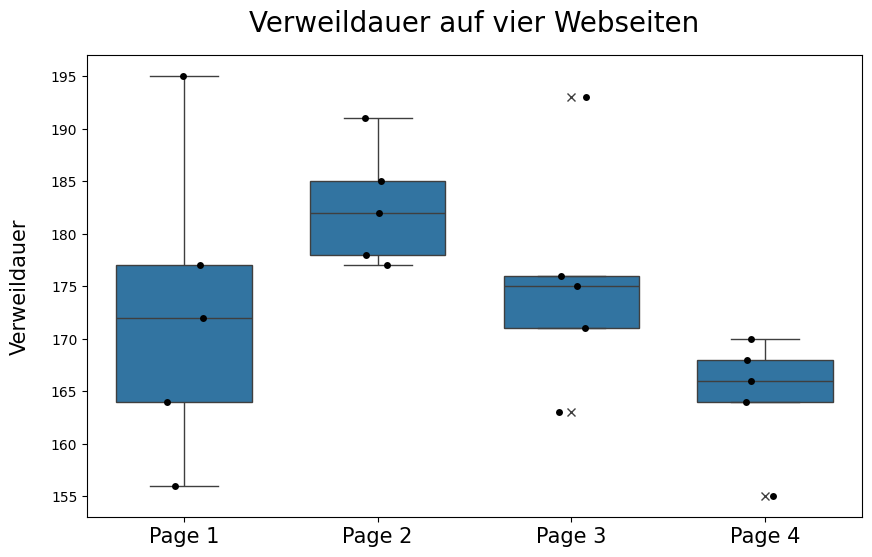

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Figurobjekt erstellen
fig = plt.figure(figsize=(10,6))

# Koordinatensystem erstellen
axi = fig.add_subplot(1,1,1)

# Boxplots zeichnen
sns.boxplot(x="Page",y="Time",data=four_sessions,ax=axi,
            width=0.7, flierprops={"marker":"x"})

# Datenwolken ergänzen => Regenwolkenplot
sns.stripplot(x="Page",y="Time",data=four_sessions,ax=axi,
                color="black", size=5)

# Achsen formatieren
axi.tick_params(axis="x", labelsize=15)
axi.set_xlabel("")
axi.set_ylabel("Verweildauer",fontsize=15,labelpad=15)
axi.set_title("Verweildauer auf vier Webseiten",fontsize=20,pad=17)

# Figur zeigen
plt.show()

Nun machen wir den Hypothesentest:

Die **Nullhypothese** ist:
- Die mittlere Verweildauer auf den vier Seiten ist gleich.

Die **Alternativhypothese** ist:
- Die mittlere Verweildauer auf den vier Seiten ist unterschiedlich.

Die **beobachtete Varianz** zwischen den mittleren Verweildauern ist:

In [ ]:
# gruppiere die Daten über die Werte der Spalte "Page"
# und bestimme den Mittelwert für jede Gruppe
mittlereZeiten = four_sessions.groupby("Page").mean()

# Bestimme die Varianz dieser mittleren Zeiten  
var_beobachtet = mittlereZeiten.var(ddof=1).iloc[0]
var_beobachtet

np.float64(55.426666666666655)

Mit **Reasampling** finden wir die folgenden Varianzen:

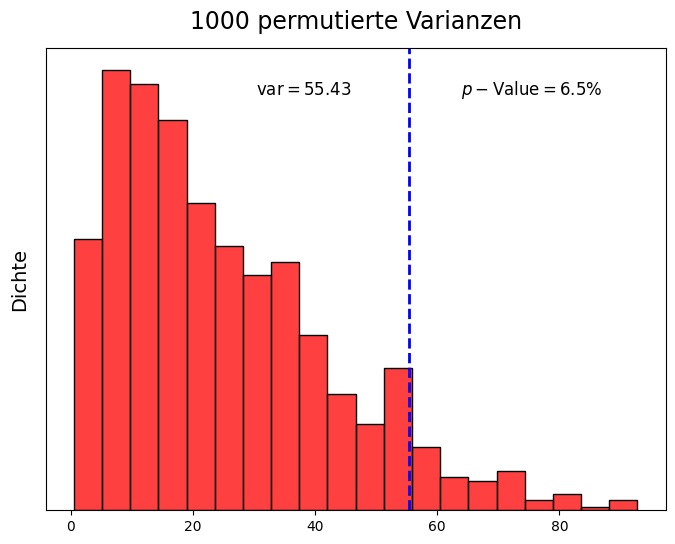

In [ ]:
# erstelle Indices für die Stichprobe 
n = four_sessions.shape[0]
idx = np.arange(n)

# mache den Permutationstest
var_permutiert = []
for _ in range(1000):
    # Permutiere die Indices zufällig
    idx_permutiert = np.random.permutation(idx)

    # mache gleich grosse Gruppen und bestimme die mittleren Zeiten
    mu_perm_1 = four_sessions["Time"].loc[idx_permutiert[:5]].mean()
    mu_perm_2 = four_sessions["Time"].loc[idx_permutiert[5:10]].mean()
    mu_perm_3 = four_sessions["Time"].loc[idx_permutiert[10:15]].mean()
    mu_perm_4 = four_sessions["Time"].loc[idx_permutiert[15:]].mean()

    # bestimme die Varianz im diesem Resample und speichere sie
    var_perm = np.array([mu_perm_1,mu_perm_2,mu_perm_3,mu_perm_4]).var(ddof=1)
    var_permutiert.append(var_perm)

# bestimme den p-Wert
p_value = 100*(var_permutiert > var_beobachtet).mean()

# --- Visualisierung

# erstelle ein Figurobjekt
fig = plt.figure(figsize=(8,6))

# erstelle ein Koordinatensystem
axi = fig.add_subplot(1,1,1)

# zeichne ein Dichtediagramm für die Varianzen der Resamples
sns.histplot(var_permutiert,stat="density",color="red",ax=axi)

# zeichne eine vertikale Linie bei der beobachteten Varianz
axi.axvline(var_beobachtet,color="blue",lw=2,linestyle="dashed")
axi.text(0.34,0.9,r"$\mathsf{var}=$"+"{v:1.2f}".format(v=var_beobachtet),
             fontsize=12,transform=plt.gca().transAxes)

# Gebe den p-Wert an
axi.text(0.67,0.9,r"$p-$"+"Value"+r"$ = $"+"{p:1.1f}%".format(p=p_value),
             fontsize=12,transform=plt.gca().transAxes)

# formatiere die Achsen
axi.set_title("1000 permutierte Varianzen",
              fontsize=17,pad=14)
axi.set_xlabel("")
axi.set_ylabel("Dichte",size=14,labelpad=12)
axi.set_yticks([])

# Figur zeigen
plt.show()

In ca. 7% der zufällig permutierten Verweildauern ist eine noch grössere Varianz als die beobachtete entstanden. Das typische Signifikanzniveau von 5% wird nicht unterschritten. 
- Daher **lehnen wir die Nullhypothese nicht ab** und gehen davon aus, dass der beobachtete Unterschied auch mit Zufall erklärbar ist.  

### <span style="color:rgb(160,0,86)">Wie werden Verteilungen verglichen?</span>

Eine ***graphische Methode*** ist das sogenannte 
- **Q-Q-Diagramm** (Quantil-Quantil-Diagramm) zum Vergleich zweier Verteilungen. 

In einem Q-Q-Diagramm werden die **Quantile der zwei Verteilungen** gegeneinander aufgetragen. 
- Jeder Punkt $\,\pmb{(x,y)}\,$ im Diagramm entspricht einem Quantil: Die $\,\pmb{x}$-Koordinate zeigt das Quantil in der ersten Verteilung, die 
$\,\pmb{y}$-Koordinate das gleiche Quantil in der zweiten Verteilung.

Wenn die beiden zu vergleichenden **Verteilungen ähnlich** sind, liegen die Punkte im Q-Q-Diagramm **annähernd auf einer Linie**. 

<center>
<img src="Bilder/QQPlot.png" width="50%" />
</center>

Wir können das Prüfen, in dem wir zufällige Werte aus der Normalverteilung $\,\pmb{\mathsf{Norm}(\mu=2,\sigma=1.5)}\,$ wählen und diese Stichprobe mit den theoretischen Quantilen der Normalverteilung vergleichen.

Wir ziehen **100 zufällige Zahlen unter dieser Verteilung**:

In [ ]:
from scipy.stats import norm, t

X = norm(loc=2,scale=1.5)
stichprobe = X.rvs(1000)

Nun bestimmen wir **100 Quantile der Normalverteilung** und der **t-Verteilung**:

In [ ]:
import numpy as np

# 500 gleichmässig verteile Wahrscheinlichkeiten im Intervall (0,1)
P = np.linspace(0,1,1002)[1:1001]

# Die 500 entsprechenden theoretische Quantile 
q_normal = X.ppf(P)
q_t = t.ppf(P, df=3, loc=2, scale=1.5)

Im **Q-Q-Diagramm** zeichnen wir die Verteilung der Stichprobe auf der $\,\pmb{y}$-Achse und die theoretische Verteilung auf der $\,\pmb{x}$-Achse:

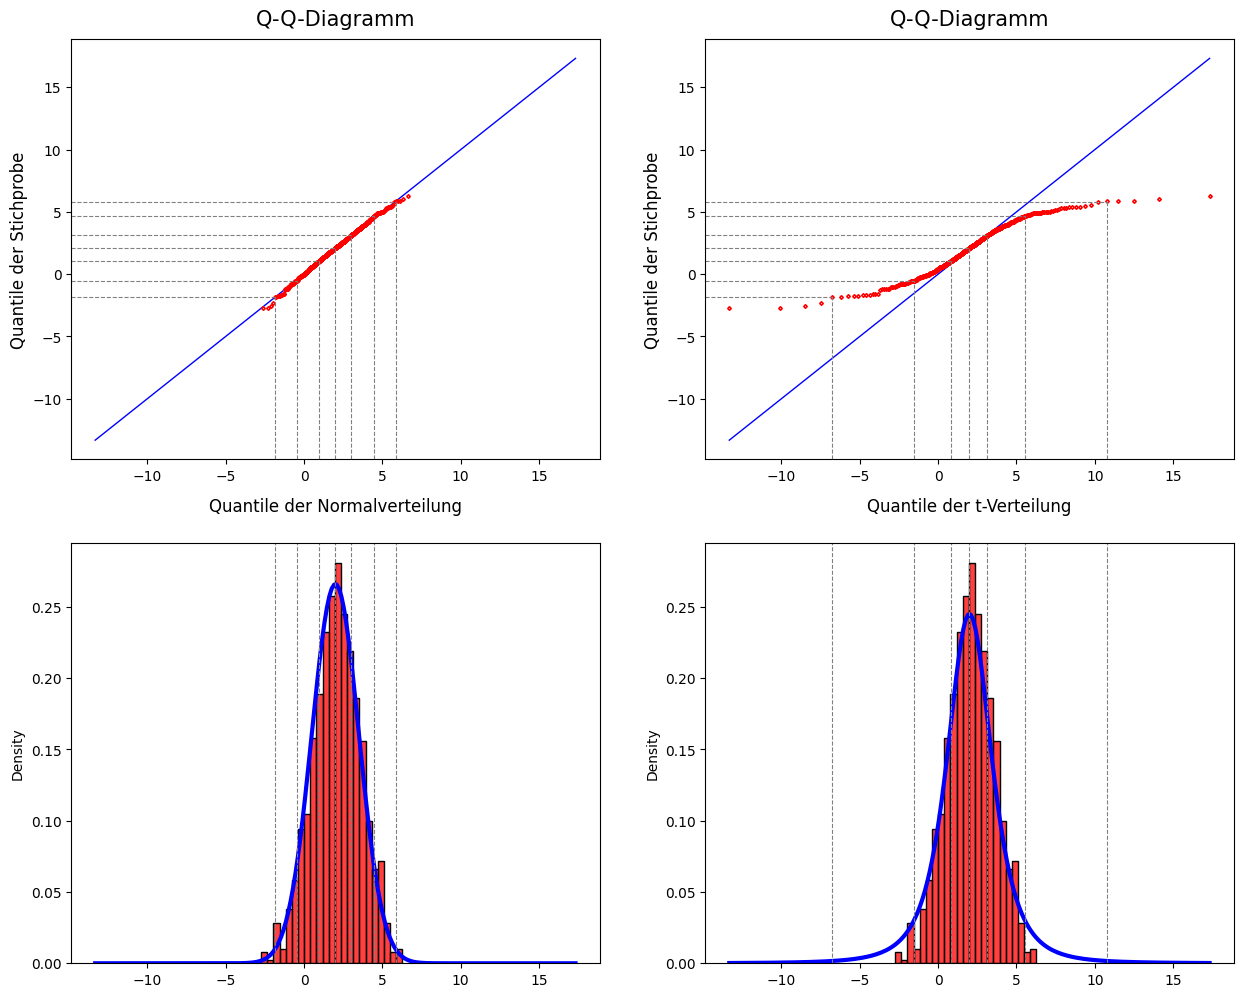

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Exemplarische Quantile zur Visualisierung 
levels = [0.005,0.05,0.25,0.5,0.75,0.95,0.995]  
stichprobe_quants = np.quantile(stichprobe,levels)
normal_quants = X.ppf(levels)
t_quants = t.ppf(levels, df=3, loc=2, scale=1.5)

# QQ-Plot Stichprobe ~ Normalverteilung
fig = plt.figure(figsize=(15,12))

ax1 = fig.add_subplot(2,2,1)
ax1.plot([q_t.min(), q_t.max()], [q_t.min(), q_t.max()],
         color="blue",lw=1)
ax1.plot(q_normal,np.sort(stichprobe),
         linestyle="None",marker="$\u25EF$",color="red",markersize=2)
ax1.set_title("Q-Q-Diagramm",fontsize=15,pad=10)
ax1.set_xlabel("Quantile der Normalverteilung",fontsize=12,labelpad=10)
ax1.set_ylabel("Quantile der Stichprobe",fontsize=12,labelpad=3)

# Quantile 
x_min, x_max = ax1.get_xlim()
y_min, y_max = ax1.get_ylim()
for xq, yq in zip(normal_quants, stichprobe_quants):
    ax1.axvline(xq,0,(yq - x_min) / (x_max - x_min), 
                color="gray", lw=0.8, linestyle="--")
    ax1.axhline(yq,0,(xq - y_min) / (y_max - y_min), 
                color="gray", lw=0.8, linestyle="--")

# QQ-Plot Stichprobe ~ t-Verteilung
ax2 = fig.add_subplot(2,2,2)
ax2.plot([q_t.min(), q_t.max()], [q_t.min(), q_t.max()],
         color="blue",lw=1)
ax2.plot(q_t,np.sort(stichprobe),
         linestyle="None",marker="$\u25EF$",color="red",markersize=2)
ax2.set_title("Q-Q-Diagramm",fontsize=15,pad=10)
ax2.set_xlabel("Quantile der t-Verteilung",fontsize=12,labelpad=10)
ax2.set_ylabel("Quantile der Stichprobe",fontsize=12,labelpad=3)

# Quantile
x_min, x_max = ax2.get_xlim()
y_min, y_max = ax2.get_ylim()
for xq, yq in zip(t_quants, stichprobe_quants):
    ax2.axvline(xq,0,(yq - x_min) / (x_max - x_min), 
                color="gray", lw=0.8, linestyle="--")
    ax2.axhline(yq,0,(xq - y_min) / (y_max - y_min), 
                color="gray", lw=0.8, linestyle="--")

# Dichtediagramm der Daten und Normalverteilung
ax3 = fig.add_subplot(2,2,3)
sns.histplot(stichprobe,stat="density",color="red",ax = ax3)
x_ = np.linspace(q_t.min(),q_t.max(),200)
ax3.plot(x_,X.pdf(x_),lw=3,color="blue")

# Quantile
for xq in normal_quants:
    ax3.axvline(x=xq, color="gray", lw=0.8, linestyle="--")

# Dichtediagramm der Daten und t-Verteilung
ax4 = fig.add_subplot(2,2,4)
sns.histplot(stichprobe,stat="density",color="red",ax = ax4)
ax4.plot(x_,t.pdf(x_, df=3, loc=2, scale=1.5),lw=3,color="blue")

# Quantile
for xq in t_quants:
    ax4.axvline(x=xq, color="gray", lw=0.8, linestyle="--")
    
# Figur zeigen
plt.show()

Die Form der Abweichung zeigt die Abweichung von der theoretischen Verteilung. 

- **Die Winkelhalbierende ist die Bezugslinie:** Sie stellt die perfekte Übereinstimmung dar. Punkte liegen nur dann auf der Gerraden, wenn jedes Quantil der Stichprobe exakt dem theoretischen Quantil entspricht.
- **Punkte oberhalb der Linie:** Die beobachteten Werte sind grösser als erwartet.
- **Punkte unterhalb der Linie:** Die beobachteten Werte sind kleiner als erwartet.

<span style="color:rgb(160,0,86)"> ***Merksatz:*** </span> Die Gerade wird immer als **Referenzlinie im QQ-Plot** gezeichnet.

Im Bild links sehen wir, dass auch eine normalverteilte Stichprobe nicht perfekt auf der Geraden liegt. 
- **Kleine Abweichungen** – insbesondere an den Enden – sind normal und zeigen die zufällige Streuung der empirischen Quantile.


### <span style="color:rgb(160,0,86)">Aufgabe 2</span>

- Laden Sie die Daten der Stichprobe in der Datei *Palette.sav* und *loans_income.csv* im Ordner Daten.
- Prüfen Sie mit einem **Q-Q-Diagramm** für alle Merkmale in diesen Daten, ob sie normalverteilt sind.   

---

### <span style="color:rgb(160,0,86)">Lösungsvorschlag</span>

Wir **laden** die Daten:

In [ ]:
import numpy as np
import pandas as pd

eggs = pd.read_spss("Daten/Palette.sav")
loans = pd.read_csv("Daten/loans_income.csv")

Wir zeichnen die **QQ-Plots** für die **Eierdaten**:

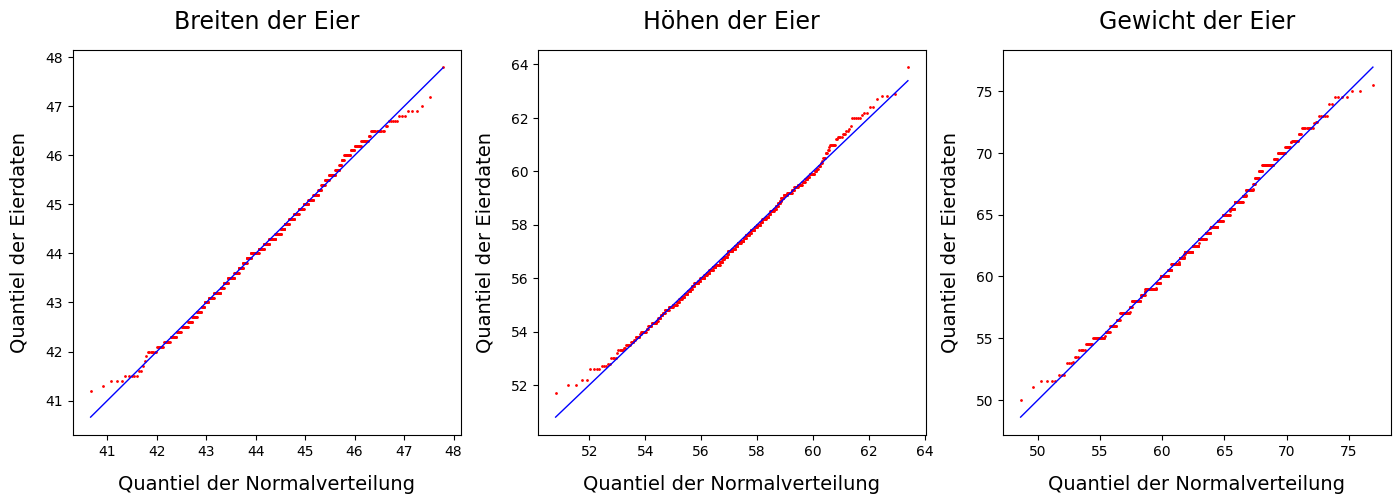

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import norm

# 750 (Anzahl Eier) gleichmässig verteile Wahrscheinlichkeiten in (0,1)
n = eggs.shape[0]
P = np.linspace(0,1,n+2)[1:n+1]

# Theoretische Quantile, falls die Breiten eine Normalverteilung haben:
mu_B = eggs["Breite"].mean()
std_B = eggs["Breite"].std(ddof=1)
X_B = norm(loc=mu_B,scale=std_B)
q_B = X_B.ppf(P)

# Theoretische Quantile, falls die Höhen eine Normalverteilung haben:
mu_H = eggs["Höhe"].mean()
std_H = eggs["Höhe"].std(ddof=1)
X_H = norm(loc=mu_H,scale=std_H)
q_H = X_H.ppf(P)

# Theoretische Quantile, falls die Gewichte eine Normalverteilung haben:
mu_G = eggs["Gewicht"].mean()
std_G = eggs["Gewicht"].std(ddof=1)
X_G = norm(loc=mu_G,scale=std_G)
q_G = X_G.ppf(P)

# --- drei QQ-Plots für die Eierdaten:

# Figurobjekt erstellen
fig = plt.figure(figsize=(17,5))

# Koordinatensystem für die Breite
ax1 = fig.add_subplot(1,3,1)

# QQ-Plot EierBreite ~ Normalverteilung
ax1.plot(q_B,eggs["Breite"].sort_values(),'ro',markersize=1)

# Referenzlinie
ax1.plot([q_B.min(), q_B.max()], [q_B.min(), q_B.max()], color="blue",lw=1)

# Achsen formatiern
ax1.set_title("Breiten der Eier",fontsize=17,pad=15)
ax1.set_xlabel("Quantiel der Normalverteilung",size=14,labelpad=12)
ax1.set_ylabel("Quantiel der Eierdaten",size=14,labelpad=12)

# Koordinatensystem für die Breite
ax2 = fig.add_subplot(1,3,2)

# QQ-Plot EierHöhe ~ Normalverteilung
ax2.plot(q_H,eggs["Höhe"].sort_values(),'ro',markersize=1)

# Referenzlinie
ax2.plot([q_H.min(), q_H.max()], [q_H.min(), q_H.max()], color="blue",lw=1)

# Achsen formatieren
ax2.set_title("Höhen der Eier",fontsize=17,pad=15)
ax2.set_xlabel("Quantiel der Normalverteilung",size=14,labelpad=12)
ax2.set_ylabel("Quantiel der Eierdaten",size=14,labelpad=12)

# Koordinatensystem für das Gewicht
ax3 = fig.add_subplot(1,3,3)

# QQ-Plot EierGewicht ~ Normalverteilung
ax3.plot(q_G,eggs["Gewicht"].sort_values(),'ro',markersize=1)

# Referenzlinie
ax3.plot([q_G.min(), q_G.max()], [q_G.min(), q_G.max()], color="blue",lw=1)

# Achsen formatieren
ax3.set_title("Gewicht der Eier",fontsize=17,pad=15)
ax3.set_xlabel("Quantiel der Normalverteilung",size=14,labelpad=12)
ax3.set_ylabel("Quantiel der Eierdaten",size=14,labelpad=12)

# Figur zeigen
plt.show()

ffff

Weil die Quantil-Quantil Wertepaare nahezug **auf einer Linie** liegen, sind die Merkmale *Breite*, *Höhe* und *Gewicht* der Eier näherungsweise **normalverteilt**.

Nun zeichnen wir noch den **QQ-Plot** für die **loans_income**-Daten:




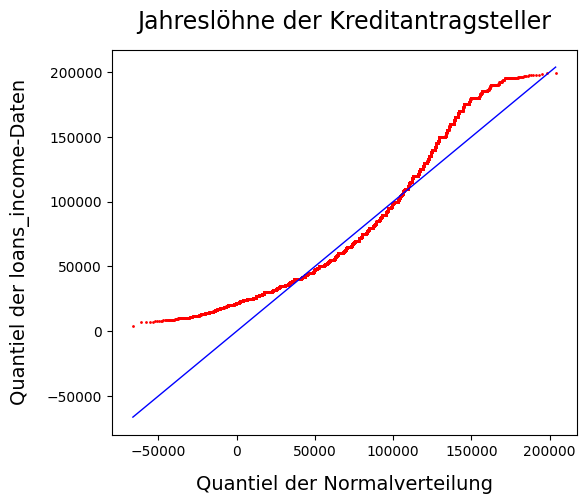

In [ ]:
# 5000 (Anzahl Löhne) gleichmässig verteile Wahrscheinlichkeiten in (0,1)
n = loans.shape[0]
P = np.linspace(0,1,n+2)[1:n+1]

# Theoretische Quantile, falls die Löhne eine Normalverteilung haben:
mu = loans["x"].mean()
std = loans["x"].std(ddof=1)
X = norm(loc=mu,scale=std)
q = X.ppf(P)

# --- QQ-Plot für die Lohndaten:

# Figurobjekt erstellen
fig = plt.figure(figsize=(6,5))

# Koordinatensystem für die Breite
axi = fig.add_subplot(1,1,1)

# QQ-Plot Löhne ~ Normalverteilung
axi.plot(q,loans["x"].sort_values(),'ro',markersize=1)

# Referenzlinie
axi.plot([q.min(), q.max()], [q.min(), q.max()], color="blue",lw=1)

# Achsen formatieren
axi.set_title("Jahreslöhne der Kreditantragsteller",fontsize=17,pad=15)
axi.set_xlabel("Quantiel der Normalverteilung",size=14,labelpad=12)
axi.set_ylabel("Quantiel der loans_income-Daten",size=14,labelpad=12)

# Figur zeigen
plt.show()

Weil die Quantil-Quantil Wertepaare **nicht auf einer Linie** liegen, sind die Jahreslöhne **nicht normalverteilt**.

---

### <span style="color:rgb(160,0,86)">Was ist der Chi-Quadrat-Test?</span>

Web-Tests gehen oft über A/B-Tests hinaus und testen ***mehrere Behandlungs-Varianten*** auf einmal. Der **Chi-Quadrat-Test** wird bei Daten verwendet, um zu prüfen, wie gut sie einer **erwarteten Verteilung** entsprechen.

Der Chi-Quadrat-Test wurde ursprünglich von **Karl Pearson** im Jahr 1900 entwickelt. Der Begriff ***chi*** stammt von dem griechischen Buchstaben $\pmb{\chi}$, den Pearson in dem Artikel verwendete.

#### <span style="color:rgb(160,0,86)">Ein Resampling-Ansatz für den Chi-Quadrat-Test</span>

Angenommen, wir testen drei verschiedene Schlagzeilen A, B und C und führen sie jeweils mit 1000 Besuchern durch. Die Ergebnisse sind in folgender Tabelle dargestellt.

$$\begin{array}{c|ccc}
& \textbf{Schlagzeile A} & \textbf{Schlagzeile B} & \textbf{Schlagzeile C} \\ \hline
\textbf{Klick} & 14 & 8 & 12\\
\textbf{kein Klick} & 986 & 992 & 988\\ 
\end{array}$$
- Die **Schlagzeilen scheinen sich deutlich zu unterscheiden.**  Schlagzeile A hat eine fast doppelt so hohe Klickrate wie B.
- Die **tatsächlichen Zahlen sind jedoch gering**.

Mit einem ***Resampling-Verfahren*** kann getestet werden, ob sich die Klickraten in einem grösseren Ausmass unterscheiden, als es der Zufall verursachen könnte. 

Für diesen Test benötigen wir die ***erwartete Verteilung der Klicks***, dass alle drei Schlagzeilen die gleiche Klickrate haben, also eine Klickrate von $$\frac{14+8+12}{1000+1000+1000}=\frac{34}{3000}=0.011\overline{3}$$ für alle drei Schlagzeilen.

Aus dieser erwarteten Klickrate können wir die ***erwarteten Häufigkeiten*** bestimmen, wenn es keinen Unterschied zwischen den Schlagzeilen gibt:

$$\begin{array}{c|ccc}
& \textbf{Schlagzeile A} & \textbf{Schlagzeile B} & \textbf{Schlagzeile C} \\ \hline
\textbf{Klick} & 11.\overline{3} & 11.\overline{3} & 11.\overline{3}\\
\textbf{kein Klick} & 988.\overline{6} & 988.\overline{6} & 988.\overline{6}\\ 
\end{array}$$
Das sogenannte **quadratische Pearson-Residuum** $$R^2=\frac{(\text{beobachtete Häufigkeit}-\text{erwartete Häufigkeit})^2}{\text{erwartete Häufigkeit}}$$ misst das Aussmass, wie stark sich die **beobachteten Häufigkeiten** und die **erwarteten Häufigkeiten** unterscheiden. 

Die **Chi-Quadrat-Metrik** $\pmb{\chi^2}$ ist definiert als die **Summe der quadrierten Pearson-Residuen**:
$$\pmb{\chi^2} = 
\pmb{R}_{\text{\small A,Klick}}^2 + \pmb{R}_{\text{\small A,kein Klick}}^2 + \pmb{R}_{\text{\small B,Klick}}^2 + \pmb{R}_{\text{\small B,kein Klick}}^2 + \pmb{R}_{\text{\small C,Klick}}^2 + \pmb{R}_{\text{\small C,kein Klick}}^2$$
wobei über **alle Zeilen** und **Spalten der Tabelle** addiert wird. 

Ob die Chi-Quadrat-Metrik für dieses Beispiel grösser ist als bei einem Zufallsmodell,  können wir mit dem folgenden **Resampling-Algorithmus** testen:


<span style="color:rgb(160,0,86)"> ***Pseudocode:*** </span>

<span style="font-family: monospace"><strong>Eingabe:</strong> Daten aus Gruppen A, B, C, D, ..., erwartete Verteilung eines Merkmals<br>
<strong>Schritt 1:</strong> Berechne den beobachteten Chi-Quadrat-Wert $\chi^2_{\text{beobachtet}}$ <br> <strong>Schritt 2:</strong> Wiederhole viele Male: <br>
$\quad\quad$ <strong>a)</strong> Lege die Werte aus allen Gruppen zusammen.<br>
$\quad\quad$ <strong>b)</strong> Teile sie zufällig in Gruppen gleicher Grösse wie A, B, C, D, ...<br>
$\quad\quad$ <strong>c)</strong> Berechne erneut den Chi-Quadrat-Wert $\chi^2_{\text{resample}}$ und speichere ihn<br>
<strong>Schritt 3:</strong> Bestimme die relative Häufigkeit, wie oft der Chi-Quadrat-Wert $\chi^2_{\text{resample}}$ grösser ist als der beobachtete Chi-Quadrat-Wert $\chi^2_{\text{beobachtet}}$. <br> <strong>Ausgabe:</strong> Der p-Wert, also die bei Schritt 3 berechnete relative Häufigkeit. <br></span>

Der **Ablauf des Testentscheids** unterscheidet sich nicht von den bisher behandelten Verfahren.

### <span style="color:rgb(160,0,86)">Aufgabe 3</span>

Laden Sie die Daten der Stichprobe in der Datei *click_rates.csv* im Ordner Daten. 
- Wie lautet die **Nullhypothese** und die entsprechende **Alternativhypothese**?
- Bestimmen Sie mit dem Resampling-Verfahren für den **Chi-Quadrat-Test** eine Menge von 1000 permutieren Summen der quadrierten Pearson-Residuen und stellen Sie die Verteilung dieser Werte in einem Dichtediagramm dar. Zeichnen Sie in das gleiche Diagramm auch die beobachtete Summe der quadrierten Pearson-Residuen ein.
- Bestimmen Sie den $\pmb{p}\textbf{-Wert}$ und machen Sie auf dem **Signifikanzniveau von 5%** einen Testentscheid.

---

### <span style="color:rgb(160,0,86)">Lösungsvorschlag</span>

Wir **laden** die Daten:

In [3]:
import numpy as np
import pandas as pd

clicks = pd.read_csv("Daten/click_rates.csv")
clicks

,Headline,Click,Rate
0,Headline A,Click,14
1,Headline A,No-click,986
2,Headline B,Click,8
3,Headline B,No-click,992
4,Headline C,Click,12
5,Headline C,No-click,988


Wir machen den Hypothesentest:

Die **Nullhypothese** ist:
- Die Anzahl Klicks für die drei Schlagzeilen unterscheidet sich nicht.

Die **Alternativhypothese** ist:
- Die Anzahl Klicks für die drei Schlagzeilen ist unterschiedlich.

Die **beobachtete** $\pmb{\chi^2}$-**Metrik** ist:

In [4]:
# erwartete Anzahl Clicks und No-clicks
N_c = clicks["Rate"][clicks["Click"]=="Click"].sum()/3
N_nc = clicks["Rate"][clicks["Click"]=="No-click"].sum()/3
erwartet = np.array(3*[N_c,N_nc])

# beobachtete Anzahl Clicks und No-clicks
beobachtet = np.array(clicks["Rate"])

# Berechung für chiQuadrat 
def chi2(n_beobachtet,n_erwartet):
    return sum((n_beobachtet-n_erwartet)**2 / n_erwartet)

chi2_beobachtet = chi2(beobachtet,erwartet)
chi2_beobachtet

np.float64(1.6659394708658917)

Mit **Reasampling** finden wir die folgenden $\chi^2$-Metriken:

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns


# Daten für das Resampling (1: Click, 0: No-click)
lst_clicks = np.array((clicks["Rate"][clicks["Click"]=="Click"].sum()*[1] + 
                       clicks["Rate"][clicks["Click"]=="No-click"].sum()*[0]))

# Resampling-Algorithmus
chi2_permutiert = []
for _ in range(1000):
    # permutiere die Daten
    lst = np.random.permutation(lst_clicks)

    # mache gleich grosse Gruppen und zähle Click's und No-click's
    A, B, C = lst[0:1000].sum(), lst[1000:2000].sum(), lst[2000:3000].sum() 
    sample = np.array([A, 1000-A, B, 1000-B, C, 1000-C])
    
    # berechne chiQuadrat im Resample und speichere es   
    chi2_permutiert.append(chi2(sample,erwartet))

# berechne p-Wert
p_value = 100*(chi2_permutiert > chi2_beobachtet).mean()

# --- Visualisierung

# Figurobjekt erstellen
fig = plt.figure(figsize=(8,6))

# Koordinatensystem erstellen
axi = fig.add_subplot(1,1,1)

# Dichtediagramm für die 1000 ChiQuadrat-Werte der Resamples
sns.histplot(chi2_permutiert,stat="density",ax=axi,color="red")

# vertikale Linie beim beobachteten ChiQuadrat-Wert
axi.axvline(chi2_beobachtet,color="blue",lw=2,linestyle="dashed")
axi.text(0.2,0.9,r"$\chi^2=$"+"{v:1.4f}".format(v=chi2_beobachtet),
             fontsize=12,transform=plt.gca().transAxes)

# Angabe der p-Werts
axi.text(0.67,0.9,r"$p-$"+"Value"+r"$ = $"+"{p:1.1f}%".format(p=p_value),
             fontsize=12,transform=plt.gca().transAxes)

# Achsen formatieren
axi.set_title("1000 permutierte Chi-Quadrat-Metriken",fontsize=17,pad=14)
axi.set_xlabel("")
axi.set_ylabel("Dichte",size=14,labelpad=12)
axi.set_yticks([])

# Figur zeigen
plt.show()

NameError: name 'np' is not defined

In ca. 40% der zufällig permutierten Werte ist eine noch grössere $\chi^2$-Metrik als die beobachtete entstanden. Das Signifikanzniveau von 5% wird klar nicht unterschritten. 
- Daher **lehnen wir die Nullhypothese nicht ab** und gehen davon aus, dass der beobachtete Unterschied mit Zufall erklärbar ist.  

---

### <span style="color:rgb(160,0,86)">Aufgabe 4</span>
Ein interessantes Beispiel ist die Forscherin **Thereza Imanishi-Kari** von der Tufts University, die 1991 beschuldigt wurde, in ihrer Forschung Daten gefälscht zu haben. Der Kongressabgeordnete John Dingell schaltete sich ein, und der Fall führte schliesslich zum Rücktritt ihres Kollegen David Baltimore von der Präsidentschaft der Rockefeller University.

Imanishi-Kari wurde nach einem langwierigen Verfahren entlastet. Ein Teil des Falles beruhte jedoch auf statistischen Beweisen für die erwartete Verteilung der Ziffern in ihren Labordaten, bei denen jede Beobachtung viele Ziffern aufwies. Die Ermittler konzentrierten sich auf die *inneren Ziffern*, von denen man annehmen kann, dass sie einer gleichmässigen Zufallsverteilung folgen. Das heisst, sie treten nach dem Zufallsprinzip auf, wobei jede Ziffer mit gleicher Wahrscheinlichkeit vorkommt (die führende Ziffer könnte überwiegend einen Wert haben, und die Endziffern könnten durch Rundung beeinflusst werden). In der Datei *imanishi_data.csv* im Ordner Daten sind die Häufigkeiten der inneren Ziffern aus den tatsächlichen Daten des Falles aufgeführt.

Laden Sie die Daten der Stichprobe in der Datei *imanishi_data.csv* im Ordner Daten.
- Zeichnen Sie ein Dichtediagramm für die Häufigkeiten der *inneren Ziffern*.
- Wie lautet die **Nullhypothese** und die entsprechende **Alternativhypothese**?
- Bestimmen Sie mit dem Resampling-Verfahren für den **Chi-Quadrat-Test** eine Menge von 1000 permutieren Summen der quadrierten Pearson-Residuen und stellen Sie die Verteilung dieser Werte in einem Dichtediagramm dar. Zeichnen Sie in das gleiche Diagramm auch die beobachtete Summe der quadrierten Pearson-Residuen ein.
- Bestimmen Sie den $\pmb{p}\textbf{-Wert}$ und machen Sie auf dem **Signifikanzniveau von 5%** einen Testentscheid.

### <span style="color:rgb(160,0,86)">Lösungsvorschlag</span>

Wir **laden** die Daten:

In [ ]:
import numpy as np
import pandas as pd

ziffern= pd.read_csv("Daten/imanishi_data.csv")
print(ziffern.columns)
ziffern.head()

Index(['Digit', 'Frequency  '], dtype='object')


,Digit,Frequency
0,0,14
1,1,71
2,2,7
3,3,65
4,4,23


Der **Spaltenname** <strong><tt>Frequency</tt></strong> hat am Ende ***zwei Leerzeichen*** - wir ändern das!

In [ ]:
ziffern.rename(columns={"Frequency  ": "Frequency"}, inplace=True)
ziffern.columns

Index(['Digit', 'Frequency'], dtype='object')

Die **Häufigkeiten der inneren Ziffern** in einem Dichtediagramm:

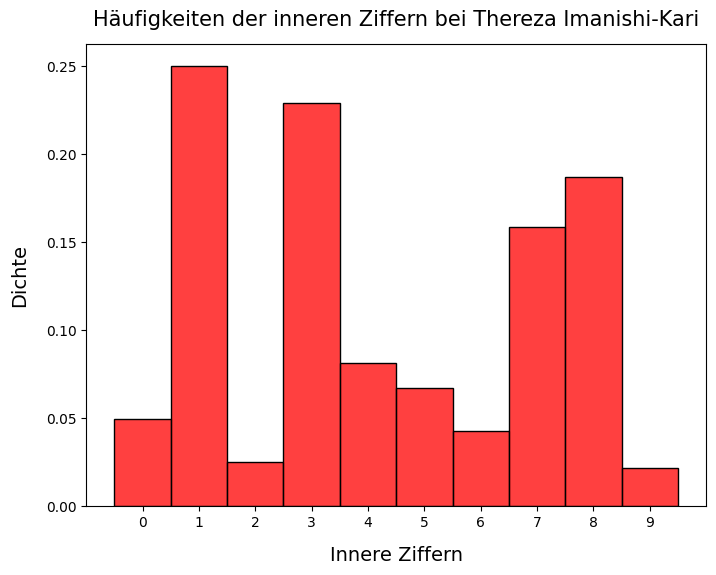

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

# Liste aus Ziffern mit gegebenen Häufigkeit gemäss Datensatz 
ziffern_beobachtet = np.array(ziffern["Frequency"].iloc[0]*[0] + 
                              ziffern["Frequency"].iloc[1]*[1] + 
                              ziffern["Frequency"].iloc[2]*[2] + 
                              ziffern["Frequency"].iloc[3]*[3] + 
                              ziffern["Frequency"].iloc[4]*[4] + 
                              ziffern["Frequency"].iloc[5]*[5] + 
                              ziffern["Frequency"].iloc[6]*[6] + 
                              ziffern["Frequency"].iloc[7]*[7] + 
                              ziffern["Frequency"].iloc[8]*[8] + 
                              ziffern["Frequency"].iloc[9]*[9])

# Figurobjekt erstellen
fig = plt.figure(figsize=(8,6))

# Koordinatensystem erestellen
axi = fig.add_subplot(1,1,1)

# Dichtediagramm für die beobachteten Ziffern
sns.histplot(ziffern_beobachtet,bins = 10,ax = axi,stat="density", color="red")

# Achsen formatieren
axi.set_title("Häufigkeiten der inneren Ziffern bei Thereza Imanishi-Kari",
              fontsize=15,pad=13)
axi.set_xlabel("Innere Ziffern",size=14,labelpad=12)
axi.set_xticks((np.array([0,1,2,3,4,5,6,7,8,9])+0.5)/10*9,
                [0,1,2,3,4,5,6,7,8,9])
axi.set_ylabel("Dichte",size=14,labelpad=12)

# Figur zeigen
plt.show()

Machen wir den Hypothesentest:

Die **Nullhypothese** ist:
- Die Häufigkeiten der innernen Ziffern sind gleich.

Die **Alternativhypothese** ist:
- Die Häufigkeiten der innernen Ziffern sind nicht gleich.

Die **beobachtete** $\pmb{\chi^2}$-**Metrik** ist:

In [ ]:
# erwartete Anzahl Ziffern
N = ziffern["Frequency"].sum()
erwartet = np.array(10*[N/10])

# beobachtete Anzahl Ziffern
beobachtet = ziffern["Frequency"].values

# ChiQuadrat berechnen
def chi2(n_beobachtet,n_erwartet):
    return sum((n_beobachtet-n_erwartet)**2 / n_erwartet)

chi2_beobachtet = chi2(beobachtet,erwartet)
chi2_beobachtet

np.float64(174.36507936507934)

Mit **Reasampling** finden wir die folgenden $\chi^2$-Metriken:

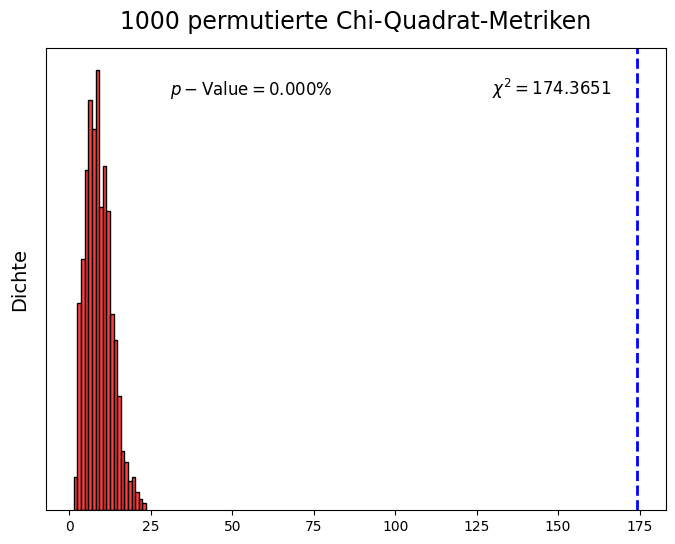

In [ ]:
from scipy.stats import randint

# erwartete Anzahl Ziffern
N = ziffern["Frequency"].sum()
erwartet = np.array(10*[N/10])

# beobachtete Anzahl Ziffern
beobachtet = ziffern["Frequency"].values

# ChiQuadrat berechnen
def chi2(n_beobachtet,n_erwartet):
    return sum((n_beobachtet-n_erwartet)**2 / n_erwartet)

chi2_beobachtet = chi2(beobachtet,erwartet)

# Zufallsvariable mit diskreter uniformer Verteilung für die Resamples
X = randint(low=0,high=10)

# Resampling-Algorithmus
chi2_permutiert = []
for _ in range(1000):
    # gleichviele uniform zufällige Zahlen wie in der Stichprobe 
    lst = X.rvs(size=N)

    # ChiQuadrat für das Resample berechen und speichern
    werte, sample = np.unique(lst,return_counts=True)
    chi2_permutiert.append(chi2(sample,erwartet))

# p-Wert berechnen
p_value = 100*(chi2_permutiert > chi2_beobachtet).mean()

# --- Visualisierung

# Figurobjekt erstellen
fig = plt.figure(figsize=(8,6))

# Koordinatensystem erstellen
axi = fig.add_subplot(1,1,1)

# Dichtediagramm für die 1000 ChiQuadrate-Werte der Resamples
sns.histplot(chi2_permutiert,stat="density",ax=axi,color="red")

# vertikale Linie beim beobachteten ChiQuadrat-Wert
axi.axvline(chi2_beobachtet,color="blue",lw=2,linestyle="dashed")
axi.text(0.72,0.9,r"$\chi^2=$"+"{v:1.4f}".format(v=chi2_beobachtet),
             fontsize=12,transform=plt.gca().transAxes)

# p-Wert ausgeben
axi.text(0.2,0.9,r"$p-$"+"Value"+r"$ = $"+"{p:1.3f}%".format(p=p_value),
             fontsize=12,transform=plt.gca().transAxes)

# Achsen formatieren
axi.set_title("1000 permutierte Chi-Quadrat-Metriken",fontsize=17,pad=14)
axi.set_xlabel("")
axi.set_ylabel("Dichte",size=14,labelpad=12)
axi.set_yticks([])

# Figur zeigen
plt.show()

In 0% der zufällig erzeugten Werte (bei denen alle Ziffern gleich wahrscheinlich sind) ist eine noch grössere $\chi^2$-Metrik als die beobachtete entstanden. Das Signifikanzniveau von 5% wird klar unterschritten. 
- Daher **lehnen wir die Nullhypothese ab** und gehen davon aus, dass die gegebenen inneren Ziffern nicht mit Zufall erklärbar sind, sofern die Annahme stimmt, dass die inneren Ziffern alle gleichwahrscheinlich sind.  

***Dieser Test deutet also darauf hin, dass die Daten möglicherweise erfunden sind.***

---

<span style="color:rgb(160,0,86)">**Bemerkung zum Fall Imanishi-Kari**</span> 

Der $\pmb{\chi^2}$-Test zeigte, dass einige Zahlenreihen auffällig regelmässig waren, um rein zufällig zu sein. Das kann auf Manipulation hindeuten, aber:
- Der Test prüft nur, ob Daten unwahrscheinlich sind, nicht, ob sie absichtlich gefälscht wurden.
- In experimentellen Daten kann es viele nicht-zufällige, aber legitime Gründe für Abweichungen geben (Messmethoden, Rundung, Nachbearbeitung etc.).
- Ausserdem wurden die Tests teilweise nachträglich und selektiv auf bestimmte Ausschnitte angewendet – was statistisch unzulässig ist.

***Imanishi-Kari*** wurde nicht deshalb freigesprochen, weil ihre Daten unauffällig waren, sondern weil die vorliegenden Beweise (inkl. der $\pmb{\chi^2}$-Test-Analyse) nicht ausreichten, um bewusste Fälschung nachzuweisen.

**Der Fall zeigt sehr gut:**
- <span style="color:rgb(160,0,86)">***Statistik kann Hinweise auf Unregelmässigkeiten geben – aber kein Motiv, keine Absicht und keine Kausalität beweisen.***</span>

![HSLU](Bilder/LogoHSLU.png)